<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-255-Data-Mining/blob/main/CLASSIFICATION_METHODS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 1 (10 points)

Use the data tuples of Table 1, which are sorted by decreasing probability value, as returned by a classifier.

For each tuple, compute the values for the number of true positives (**TP**), false positives (**FP**), true negatives (**TN**), and false negatives (**FN**). Compute the true positive rate (**TPR**) and false positive rate (**FPR**).  
**(4 points)**

Plot the ROC curve for the data.  
**(6 points)**

![Table 1: Tuples sorted by decreasing score, where the score is the value returned by a probabilistic classifier.]

**Table 1:** Tuples sorted by decreasing score, where the score is the value returned by a probabilistic classifier.

| Tuple # | Class | Probability |
|--------:|:-----:|------------:|
| 1 | P | 0.95 |
| 2 | N | 0.85 |
| 3 | P | 0.78 |
| 4 | P | 0.66 |
| 5 | N | 0.60 |
| 6 | P | 0.55 |
| 7 | N | 0.53 |
| 8 | N | 0.52 |
| 9 | N | 0.51 |
| 10 | P | 0.40 |


##Answer:




- **Total Positives (P)** = 5 (tuples 1, 3, 4, 6, 10)
- **Total Negatives (N)** = 5 (tuples 2, 5, 7, 8, 9)

slide a threshold from highest to lowest probability. At each step, classify the current tuple as **predicted Positive**, and all remaining tuples below as **predicted Negative**.
- **TPR** = TP / (TP + FN) = TP / 5
- **FPR** = FP / (FP + TN) = FP / 5

## Confusion Matrix Values at Each Threshold

| # | Class | Prob | TP | FP | TN | FN | TPR | FPR |
|---|-------|------|----|----|----|----|-----|-----|
| 1 | P | 0.95 | 1 | 0 | 5 | 4 | 0.2 | 0.0 |
| 2 | N | 0.85 | 1 | 1 | 4 | 4 | 0.2 | 0.2 |
| 3 | P | 0.78 | 2 | 1 | 4 | 3 | 0.4 | 0.2 |
| 4 | P | 0.66 | 3 | 1 | 4 | 2 | 0.6 | 0.2 |
| 5 | N | 0.60 | 3 | 2 | 3 | 2 | 0.6 | 0.4 |
| 6 | P | 0.55 | 4 | 2 | 3 | 1 | 0.8 | 0.4 |
| 7 | N | 0.53 | 4 | 3 | 2 | 1 | 0.8 | 0.6 |
| 8 | N | 0.52 | 4 | 4 | 1 | 1 | 0.8 | 0.8 |
| 9 | N | 0.51 | 4 | 5 | 0 | 1 | 0.8 | 1.0 |
| 10 | P | 0.40 | 5 | 5 | 0 | 0 | 1.0 | 1.0 |

**Example (Tuple 4, threshold = 0.66):**
The top-4 tuples are predicted P. Among them, tuples 1, 3, 4 are actually P (so TP = 3), tuple 2 is actually N (FP = 1). The remaining 6 are predicted N: tuples 5, 7, 8, 9 are actually N (TN = 4), and tuples 6, 10 are actually P (FN = 2).

TPR = 3/5 = 0.6, FPR = 1/5 = 0.2.

## ROC Curve

The points (FPR, TPR) to plot, in order, are:

(0, 0) → (0.0, 0.2) → (0.2, 0.2) → (0.2, 0.4) → (0.2, 0.6) → (0.4, 0.6) → (0.4, 0.8) → (0.6, 0.8) → (0.8, 0.8) → (1.0, 0.8) → (1.0, 1.0)


The ROC curve hugs the upper-left region, well above the diagonal random baseline. Notice the pattern:

- Every **P** tuple produces a **vertical step up** (TPR increases by 1/5 = 0.2, FPR unchanged).
- Every **N** tuple produces a **horizontal step right** (FPR increases by 1/5 = 0.2, TPR unchanged).

The classifier looks reasonable overall but stumbles at the bottom of the ranking — three negatives (tuples 7, 8, 9) appear before the last positive (tuple 10), which forces the curve to travel rightward along TPR = 0.8 before the final jump to (1.0, 1.0). The **AUC** for this ROC curve is **0.76** (using the trapezoidal rule: 0.2 × 0.6 + 0.2 × 0.8 + 0.4 × 0.8 + 0.2 × 1.0 = 0.12 + 0.16 + 0.32 + 0.20 = 0.76).

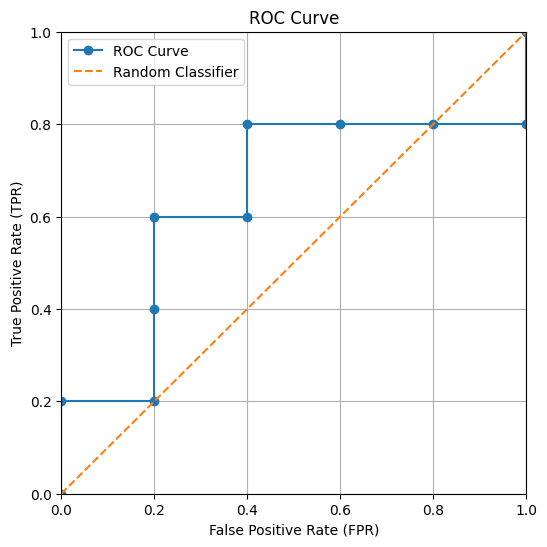

##Problem 2(10 points)

Feature selection aims to select a subset of features that will be used in training. In general, there are three major types of feature selection strategy: filter method, wrapper method and embedded method.

1. Which type of feature selection strategy does Fisher Score belong to?
   Please justify your answer using 1–2 sentences. *(2 points)*

2. Suppose we have six training examples shown below. Calculate Fisher scores for θ₀ and θ₁ and find out which one is more discriminative. *(2 points)*

| example | θ₀ | θ₁ | label |
|---------|----|----|-------|
| 1       | 96 | 33 | -     |
| 2       | 86 | 30 | +     |
| 3       | 78 | 29 | +     |
| 4       | 92 | 36 | -     |
| 5       | 80 | 35 | +     |
| 6       | 90 | 32 | +     |

3. Which type of feature selection strategy does LASSO belong to?
   Please justify your answer using 1–2 sentences. *(2 points)*

4. Denoting the vector of feature coefficients as **w**, suppose we have a tuning parameter λ for LASSO (i.e. the LASSO penalty term is λ‖**w**‖₁).

   - If λ goes to infinity, what would happen to **w**? *(2 points)*
   - Why? *(2 points)*

##Answer:

Feature selection aims to select a subset of features that will be used in training. In general, there are three major types of feature selection strategy: **filter method**, **wrapper method**, and **embedded method**.


### 1. Which type of feature selection strategy does Fisher Score belong to? *(2 points)*

**Fisher Score belongs to the filter method.**

It scores each feature independently of any learning algorithm by measuring the ratio of between-class separation to within-class variance, relying only on statistical properties of the data rather than on model performance.



### 2. Calculate Fisher Scores for θ₀ and θ₁ *(2 points)*

| example | θ₀ | θ₁ | label |
|:-------:|:--:|:--:|:-----:|
|    1    | 96 | 33 |   −   |
|    2    | 86 | 30 |   +   |
|    3    | 78 | 29 |   +   |
|    4    | 92 | 36 |   −   |
|    5    | 80 | 35 |   +   |
|    6    | 90 | 32 |   +   |

Using the Fisher Score formula:

$$F = \frac{(\mu_+ - \mu_-)^2}{\sigma_+^2 + \sigma_-^2}$$

**Step 1 — Class means:**

- Positive class (+): examples 2, 3, 5, 6
  - $\mu_+^{\theta_0} = (86+78+80+90)/4 = 83.5$
  - $\mu_+^{\theta_1} = (30+29+35+32)/4 = 31.5$
- Negative class (−): examples 1, 4
  - $\mu_-^{\theta_0} = (96+92)/2 = 94$
  - $\mu_-^{\theta_1} = (33+36)/2 = 34.5$

**Step 2 — Within-class variances:**

For θ₀:
- $\sigma_+^2 = \tfrac{(86-83.5)^2+(78-83.5)^2+(80-83.5)^2+(90-83.5)^2}{4} = \tfrac{91}{4} = 22.75$
- $\sigma_-^2 = \tfrac{(96-94)^2+(92-94)^2}{2} = \tfrac{8}{2} = 4$

For θ₁:
- $\sigma_+^2 = \tfrac{(30-31.5)^2+(29-31.5)^2+(35-31.5)^2+(32-31.5)^2}{4} = \tfrac{21}{4} = 5.25$
- $\sigma_-^2 = \tfrac{(33-34.5)^2+(36-34.5)^2}{2} = \tfrac{4.5}{2} = 2.25$

**Step 3 — Fisher Scores:**

$$F(\theta_0) = \frac{(83.5 - 94)^2}{22.75 + 4} = \frac{110.25}{26.75} \approx 4.12$$

$$F(\theta_1) = \frac{(31.5 - 34.5)^2}{5.25 + 2.25} = \frac{9}{7.5} = 1.20$$

**∴ θ₀ is more discriminative** since $F(\theta_0) \approx 4.12 > F(\theta_1) = 1.20$.



### 3. Which type of feature selection strategy does LASSO belong to? *(2 points)*

**LASSO belongs to the embedded method.**

It performs feature selection *during* model training by adding an L1 penalty to the loss function, which simultaneously fits the model and drives the coefficients of irrelevant features to exactly zero as part of optimization.


### 4. LASSO with tuning parameter λ *(4 points)*

**What happens to w as λ → ∞?**

All coefficients are driven to zero: $\mathbf{w} \to \mathbf{0}$.

**Why?**

The LASSO objective is:

$$\min_{\mathbf{w}} \;\; \mathcal{L}(\mathbf{w}) + \lambda \|\mathbf{w}\|_1$$

As $\lambda \to \infty$, the penalty term $\lambda \|\mathbf{w}\|_1$ completely dominates the data-fit loss. The only way to keep the objective finite is to make $\|\mathbf{w}\|_1 = 0$, forcing every component of **w** to zero. Intuitively, the model is being penalized so heavily for any nonzero coefficient that it abandons fitting the data entirely and predicts a constant.